# B10 · Let database cells talk

Implement and defend cell-level relational attention. **PROVIDED** supplies plumbing, **TODO** is your live implementation, **CHECK** gives immediate feedback, and **EXIT** requires your explanation.

The notebook runs fresh CPU mechanism checks and replays complete saved native contexts. It does not train RT, load its released weights or reproduce a paper AUROC. Tier C synthetic fixture isolates operations; Tier B real F1 contexts audit temporal evidence.

Read [RT-v1 §§3–5](https://arxiv.org/html/2510.06377v1).

In [1]:
# @colab-bootstrap — self-contained; no repository imports.
import sys, subprocess, importlib.util
for package in ['numpy','torch','einops','ml_dtypes']:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable,'-m','pip','install',package])
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import base64, hashlib, io, json, zipfile, tempfile, types
from pathlib import Path
from IPython.display import display, Markdown
torch.set_num_threads(1)
TYPES=('number','text','datetime','boolean')
print('Runtime:',torch.__version__, 'Author verification: torch2.13.0+cpu, float64')

Runtime: 2.13.0+cpu Author verification: torch2.13.0+cpu, float64


## Concept recap and worked example

A primary key identifies a row; a foreign key points to a parent row. A task table attaches a prediction target to an entity and a cutoff. A cell token represents one feature value. A mask replaces a hidden value before encoding.

Three tables: taskT0(row100) and old taskT1(row101) both reference customerC0(row10); orderO0(row20) also references C0. CustomerC1(row11) is unrelated. Our nine cells are T0.y, T0.time, C0.age, C0.name, O0.amount, O0.time, T1.y, T1.time, C1.age; slot9 is padding.

Feature attention reads the same row and parents; neighbor attention reads children. Column attention requires BOTH table and column identity. Full attention reads all admitted non-padding cells. Reader is the matrix row; source is its column. Empty neighbor sets return zero.

**Predict:** Can T0.y read O0.amount through feature attention? What changes under full attention?

## Model architecture

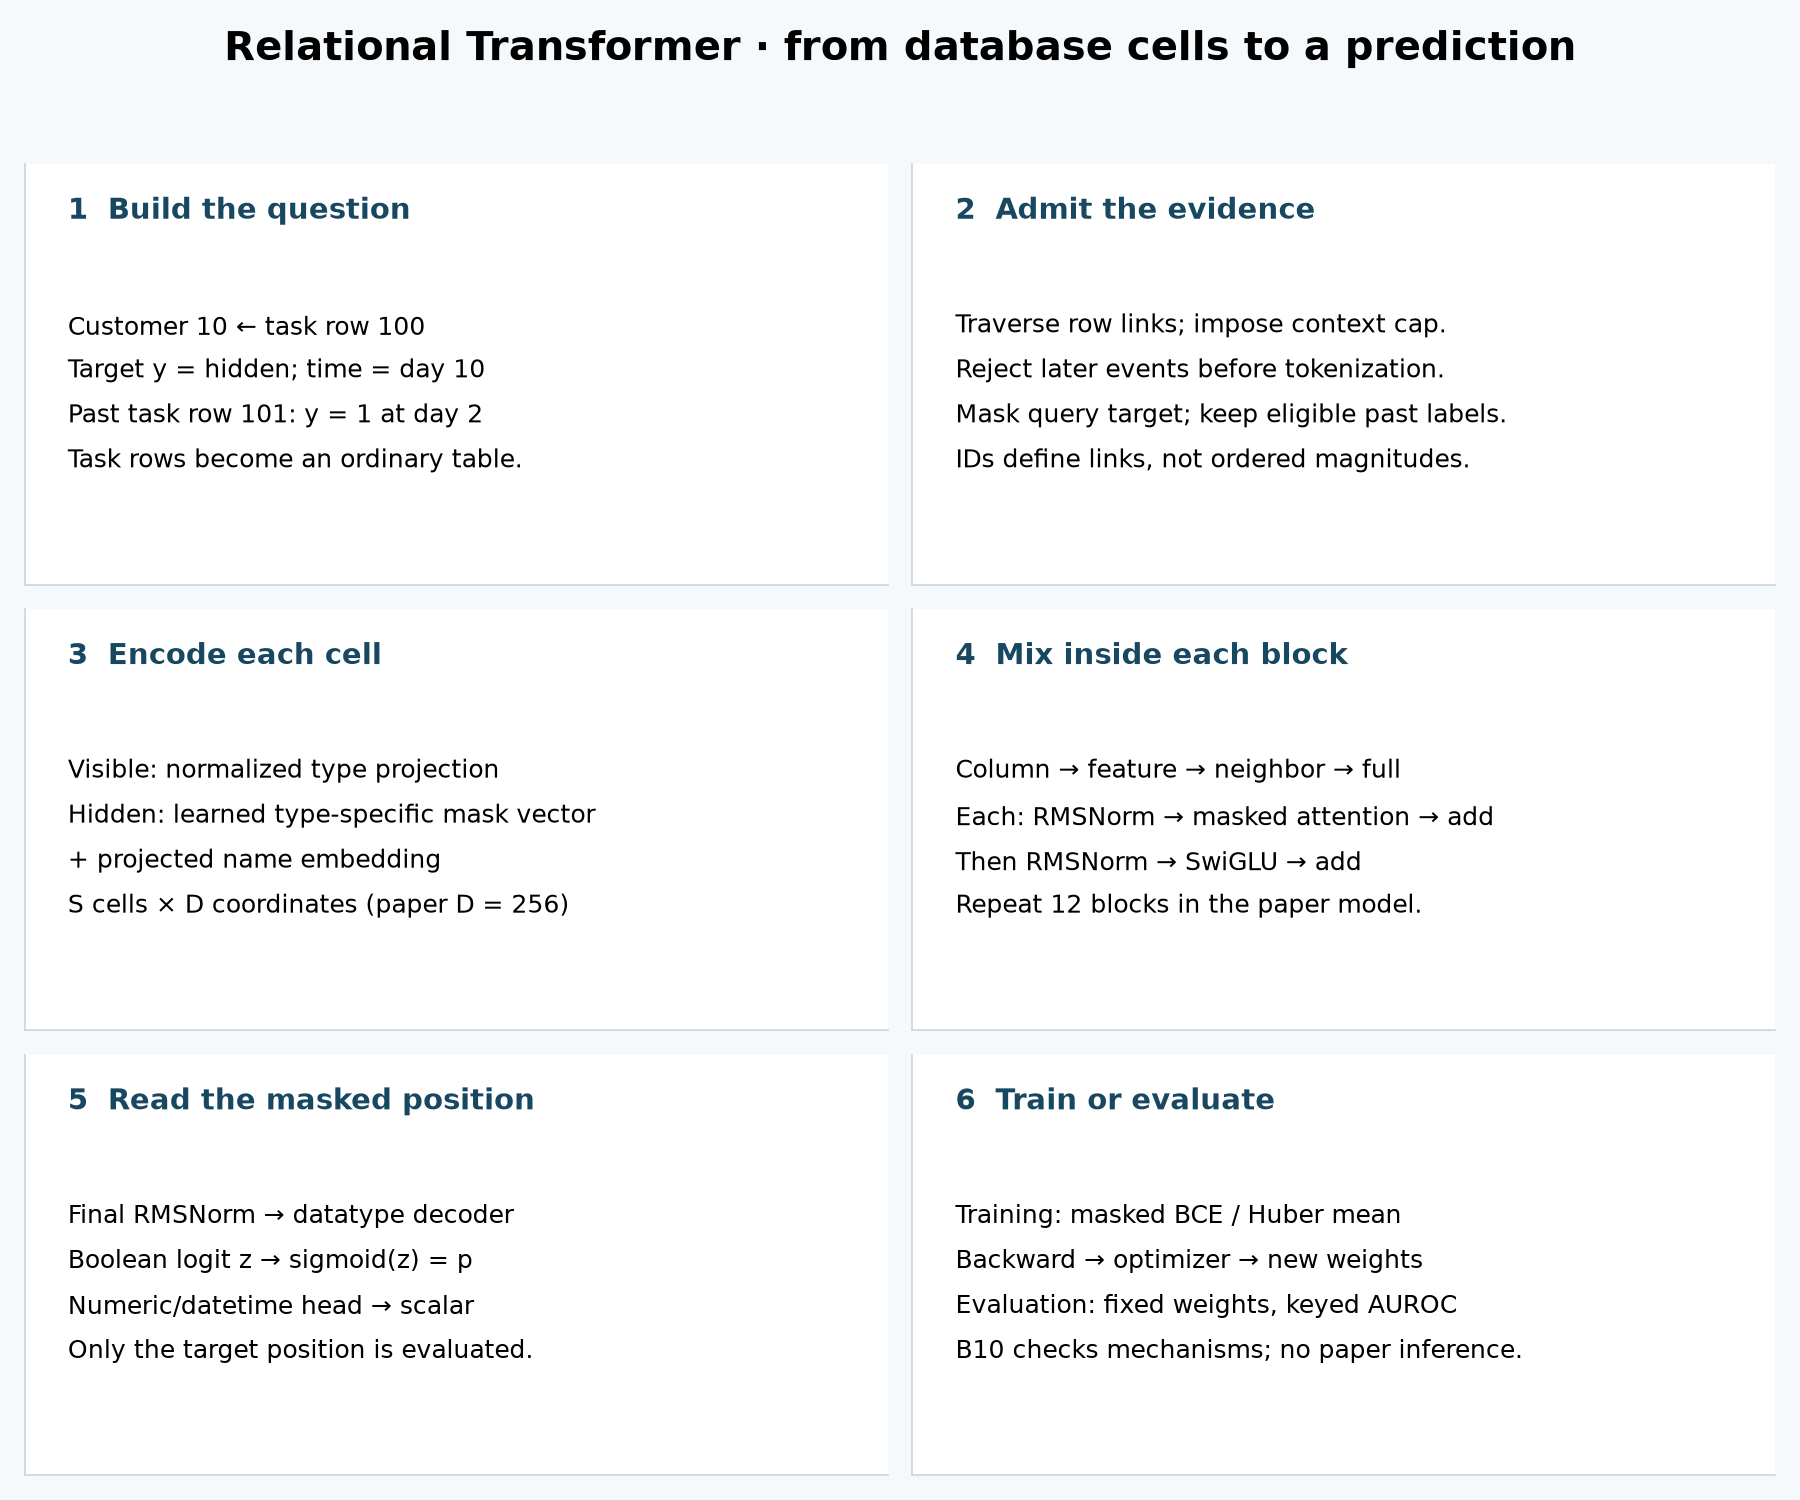

Value/type projection or learned mask + projected name → four attention sublayers with residual additions → SwiGLU → typed decoder. RMSNorm rescales each vector by its root mean square. SwiGLU multiplies a smooth-activated projected stream by a second projected stream. Boolean logits use BCE; numeric/datetime predictions use Huber loss. The loss averages only masked positions.

Original:12blocks,width256,8heads,FF1024,MiniLM384,bfloat16. Fixture:2blocks,width16,4heads,FF32,illustrative text/name width6,float64. These explicit deviations make this a mechanism check. No real pretrained semantic encoding is claimed.

## Permissions before weights

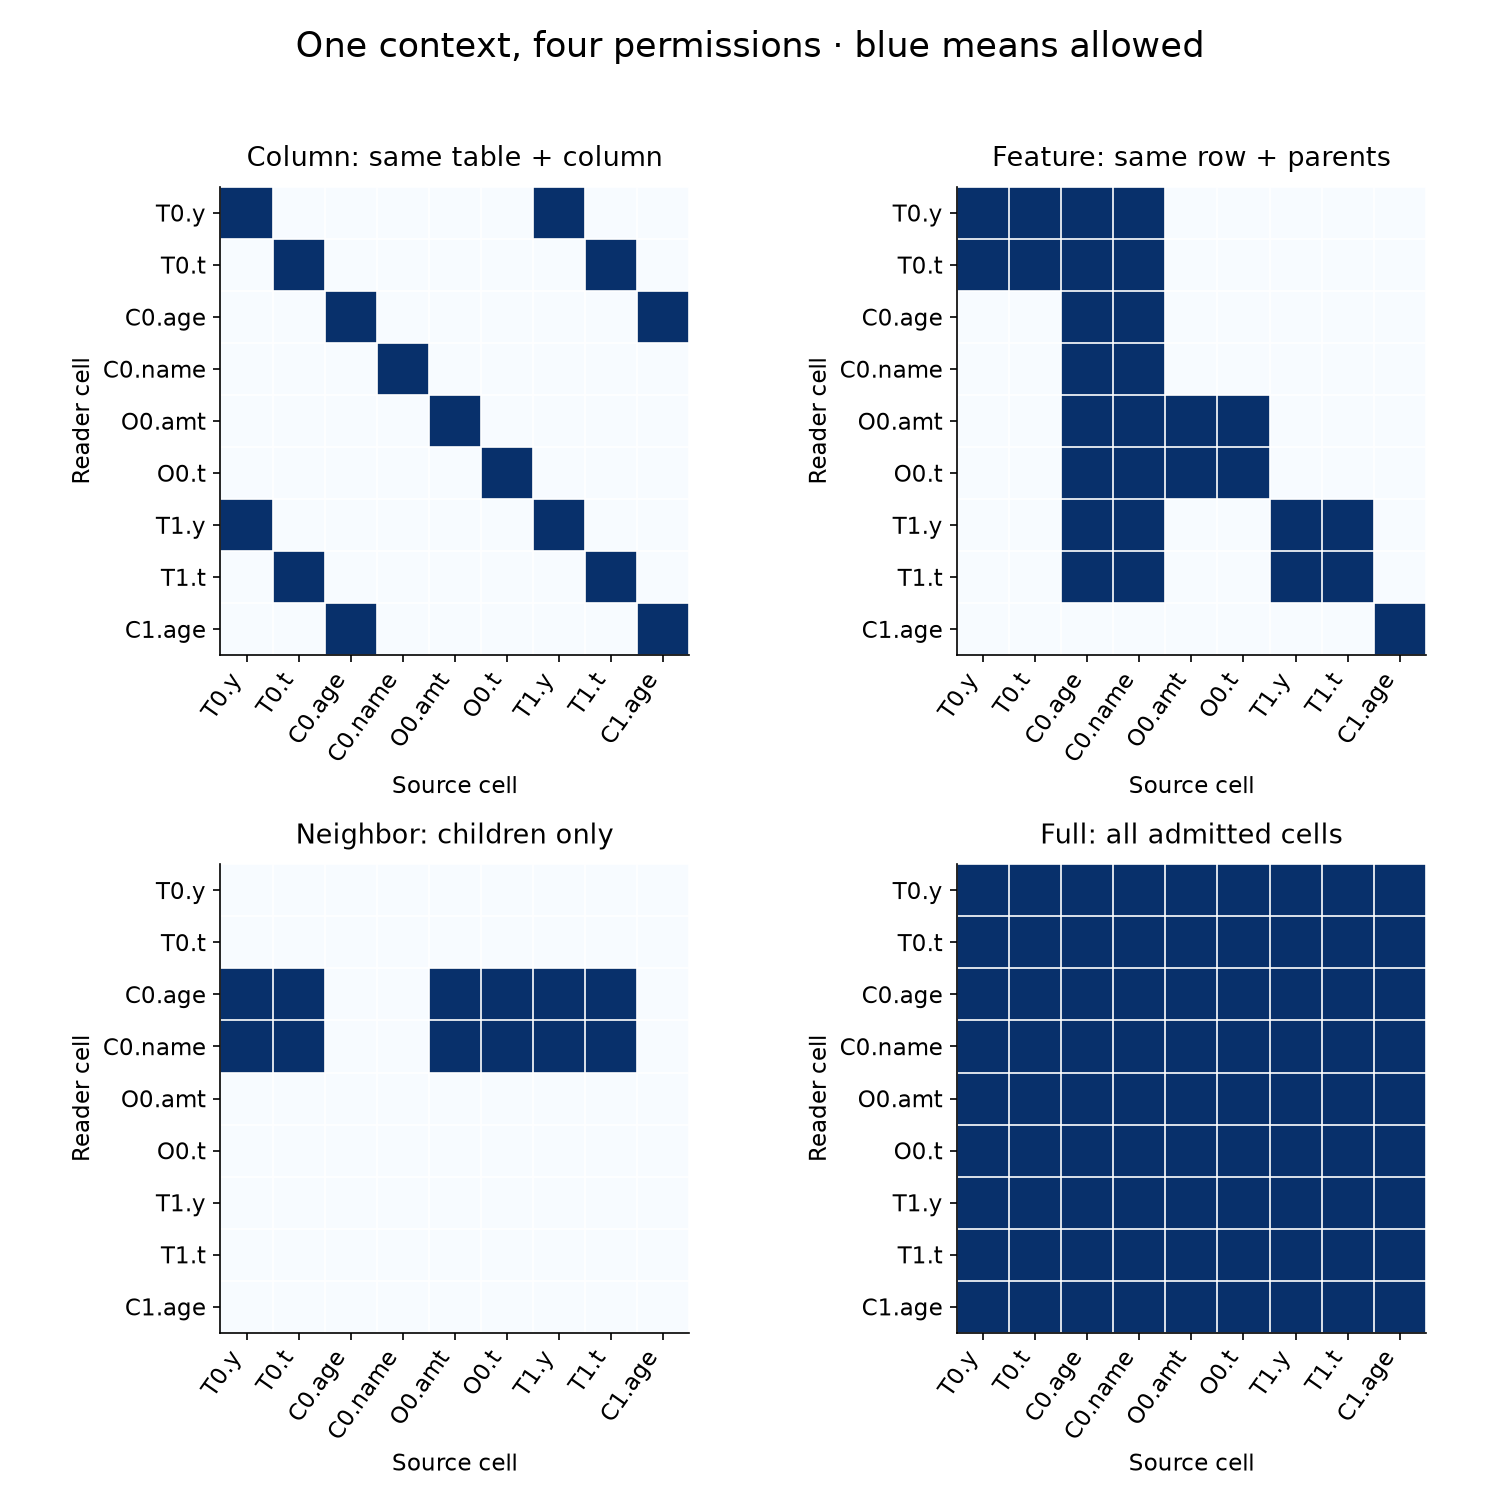

Blue allows a source; it does not fix the learned weight. A query–key score is a dot product divided by the square root of per-head width. Softmax normalizes permitted scores; their weighted values make the update. An empty set must avoid softmax of all negative infinities.

In [2]:
# PROVIDED · relationship metadata; independent scalar checker
def fixture():
    # Three tables: task(0), customer(1), order(2). Row IDs are global.
    node=torch.tensor([[100,100,10,10,20,20,101,101,11,-1]])
    b=dict(node_idxs=node, f2p_nbr_idxs=torch.tensor([[[10],[10],[-2],[-2],[10],[10],[10],[10],[-2],[-2]]]),
           table_name_idxs=torch.tensor([[0,0,1,1,2,2,0,0,1,-1]]),
           col_name_idxs=torch.tensor([[0,1,0,2,0,1,0,1,0,-1]]),is_padding=node<0)
    return b

def oracle(b):
    n=b['node_idxs'].shape[1];out={k:torch.zeros((1,n,n),dtype=torch.bool) for k in ('col','feat','nbr','full')}
    for i in range(n):
      for j in range(n):
        if b['is_padding'][0,i] or b['is_padding'][0,j]:continue
        a=int(b['node_idxs'][0,i]);c=int(b['node_idxs'][0,j])
        out['col'][0,i,j]=bool(b['table_name_idxs'][0,i]==b['table_name_idxs'][0,j] and b['col_name_idxs'][0,i]==b['col_name_idxs'][0,j])
        out['feat'][0,i,j]=(a==c or c in b['f2p_nbr_idxs'][0,i].tolist())
        out['nbr'][0,i,j]=a in b['f2p_nbr_idxs'][0,j].tolist()
        out['full'][0,i,j]=True
    return out

## TODO · relational_masks

Construct all four B×S×S permissions from row, parent, table, column and padding metadata. Neither an equal column ID across tables nor a reversed foreign-key direction is sufficient.

Write this function, then run the CHECK. It will be used in later computations; do not edit the check.

In [3]:
def relational_masks(batch):
    """Return B×S×S Boolean permissions; rows are readers, columns are sources."""
    node = batch['node_idxs']; parents = batch['f2p_nbr_idxs']
    valid = ~batch['is_padding']
    pair = valid[:, :, None] & valid[:, None, :]
    same_row = node[:, :, None] == node[:, None, :]
    to_parent = (node[:, None, :, None] == parents[:, :, None, :]).any(-1)
    from_child = to_parent.transpose(1, 2)
    same_column = ((batch['table_name_idxs'][:, :, None] == batch['table_name_idxs'][:, None, :]) &
                   (batch['col_name_idxs'][:, :, None] == batch['col_name_idxs'][:, None, :]))
    return {'col': same_column & pair, 'feat': (same_row | to_parent) & pair,
            'nbr': from_child & pair, 'full': pair}

In [4]:
# CHECK
b=fixture()
for kind,expected in oracle(b).items():
    assert torch.equal(relational_masks(b)[kind],expected),kind
print('CHECK: four directed masks and padding')

CHECK: four directed masks and padding


## TODO · safe_attention

Compute B×H×S×d attention from scores and permissions. Forbidden keys get no weight; empty sets produce zero with finite gradients.

Write this function, then run the CHECK. It will be used in later computations; do not edit the check.

In [5]:
def safe_attention(q, k, v, allowed):
    """Dense scaled dot product; empty permission rows have exactly zero output.

    q/k/v are B×H×S×d; allowed is B×S×S. No softmax over a row of -inf.
    """
    scores = q @ k.transpose(-2, -1) / q.shape[-1] ** 0.5
    permit = allowed[:, None]
    has_key = permit.any(-1, keepdim=True)
    scores = scores.masked_fill(~permit, -torch.inf)
    scores = torch.where(has_key, scores, torch.zeros_like(scores))
    weights = torch.softmax(scores, dim=-1) * permit
    return weights @ v

In [6]:
# CHECK
q=torch.zeros(1,1,2,2,dtype=torch.float64)
v=torch.tensor([[[[2.,0.],[6.,0.]]]],dtype=torch.float64)
a=torch.tensor([[[True,True],[False,False]]])
assert torch.equal(safe_attention(q,q,v,a),torch.tensor([[[[4.,0.],[0.,0.]]]],dtype=torch.float64))
print('CHECK: equal-score mean4 and empty-set zero')

CHECK: equal-score mean4 and empty-set zero


## TODO · eligible_rows

Filter evidence by known event and arrival times, a cutoff and completed label horizons. This is a separate strict course policy; unknown times fail closed.

Write this function, then run the CHECK. It will be used in later computations; do not edit the check.

In [7]:
def eligible_rows(event_time, available_at, cutoff, is_label, horizon):
    """Strict COURSE visibility policy, not a repair of RT's released sampler.

    Units must match. Unknown event/arrival times fail closed. Labels become usable
    only when both their outcome window has closed and their availability time passed.
    """
    known = torch.isfinite(event_time) & torch.isfinite(available_at)
    return known & (event_time <= cutoff) & (available_at <= cutoff) & (~is_label | (event_time + horizon <= cutoff))

In [8]:
# CHECK
t=torch.tensor([7.,8.,12.]);arrival=torch.tensor([7.,11.,9.]);label=torch.tensor([False,True,False])
assert eligible_rows(t,arrival,10.,label,3.).tolist()==[True,False,False]
print('CHECK: event, arrival and outcome completion')

CHECK: event, arrival and outcome completion


In [9]:
# CHECK · additional adversarial examples
def checks():
    b=fixture();actual=relational_masks(b)
    for key,expected in oracle(b).items():assert torch.equal(actual[key],expected),key+' has wrong cell access'
    assert actual['feat'][0,0,2] and not actual['feat'][0,2,0], 'FK direction reversed'
    assert actual['nbr'][0,2,4] and not actual['nbr'][0,4,2], 'Neighbor direction reversed'
    assert not actual['col'][0,0,2], 'Same column ID in different tables is not one column'
    q=torch.zeros(1,1,3,2,dtype=torch.float64)
    v=torch.tensor([[[[2.,0.],[6.,0.],[30.,0.]]]],dtype=torch.float64,requires_grad=True)
    mask=torch.tensor([[[True,True,False],[False,False,False],[True,False,False]]])
    out=safe_attention(q,q,v,mask)
    assert torch.equal(out,torch.tensor([[[[4.,0.],[0.,0.],[2.,0.]]]],dtype=torch.float64)), 'Empty neighbor sets must produce zero, not NaN'
    out.sum().backward();assert torch.isfinite(v.grad).all() and not v.grad[0,0,2].any(), 'Forbidden value affected gradient'
    # Day units; unknown arrival is rejected. Historical labels require completed horizon.
    times=torch.tensor([7.,11.,8.,6.,7.]);arrivals=torch.tensor([7.,9.,8.,float('nan'),12.]);labels=torch.tensor([False,False,True,False,False])
    keep=eligible_rows(times,arrivals,10.,labels,3.)
    assert keep.tolist()==[True,False,False,False,False], 'Time, arrival, or label horizon missing'
    return {'status':'PASS','mask_pairs':400,'contracts':['directed FK masks','table-qualified columns','empty neighborhoods','forbidden gradient','event/arrival/horizon visibility']}
print(checks())

{'status': 'PASS', 'mask_pairs': 400, 'contracts': ['directed FK masks', 'table-qualified columns', 'empty neighborhoods', 'forbidden gradient', 'event/arrival/horizon visibility']}


## PROVIDED · visible attention projections and residual block

Your `safe_attention` is called by the projection module; your `relational_masks` is called by the complete model. The four sublayers run column→feature→neighbor→full. This sequence is part of the architecture, even though the full layer has broad permissions.

### MaskedAttention

In [10]:
class MaskedAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__(); self.num_heads = num_heads
        self.wq = nn.Linear(d_model, d_model, bias=False)
        self.wk = nn.Linear(d_model, d_model, bias=False)
        self.wv = nn.Linear(d_model, d_model, bias=False)
        self.wo = nn.Linear(d_model, d_model, bias=False)
    def forward(self, x, block_mask):
        b, s, d = x.shape; h = self.num_heads
        q, k, v = [layer(x).reshape(b,s,h,d//h).transpose(1,2) for layer in (self.wq,self.wk,self.wv)]
        mixed = safe_attention(q,k,v,block_mask)
        return self.wo(mixed.transpose(1,2).reshape(b,s,d))

### FFN

In [11]:
class FFN(nn.Module):
    """SwiGLU: one projected stream gates another; project back to D."""
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w1=nn.Linear(d_model,d_ff,bias=False)
        self.w2=nn.Linear(d_ff,d_model,bias=False)
        self.w3=nn.Linear(d_model,d_ff,bias=False)
    def forward(self,x):return self.w2(F.silu(self.w1(x))*self.w3(x))

### RelationalBlock

In [12]:
class RelationalBlock(nn.Module):
    def __init__(self,d_model,num_heads,d_ff):
        super().__init__()
        self.norms=nn.ModuleDict({k:nn.RMSNorm(d_model) for k in ('feat','nbr','col','full','ffn')})
        self.attns=nn.ModuleDict({k:MaskedAttention(d_model,num_heads) for k in ('feat','nbr','col','full')})
        self.ffn=FFN(d_model,d_ff)
    def forward(self,x,masks):
        for kind in ('col','feat','nbr','full'):
            x=x+self.attns[kind](self.norms[kind](x),masks[kind])
        return x+self.ffn(self.norms['ffn'](x))

### Typed encoder, masked loss and decoder

The hidden target is absent from the value representation but remains the truth used by the loss. Therefore a target intervention should preserve predictions and change loss. Text masking is unsupported in this release. Values must be finite preprocessed tensors; missing and padded cells are managed by metadata.

In [13]:
class RelationalTransformer(nn.Module):
    """Same parameter names and operations as pinned RT-v1; dense CPU attention."""
    def __init__(self,num_blocks,d_model,d_text,num_heads,d_ff):
        super().__init__()
        dims={'number':1,'text':d_text,'datetime':1,'col_name':d_text,'boolean':1}
        self.enc_dict=nn.ModuleDict({t:nn.Linear(n,d_model) for t,n in dims.items()})
        self.dec_dict=nn.ModuleDict({t:nn.Linear(d_model,dims[t]) for t in TYPES})
        self.norm_dict=nn.ModuleDict({t:nn.RMSNorm(d_model) for t in dims})
        self.mask_embs=nn.ParameterDict({t:nn.Parameter(torch.randn(d_model)) for t in TYPES})
        self.blocks=nn.ModuleList([RelationalBlock(d_model,num_heads,d_ff) for _ in range(num_blocks)])
        self.norm_out=nn.RMSNorm(d_model);self.d_model=d_model
    def encode(self,batch):
        valid=~batch['is_padding'];hidden=batch['masks']
        x=self.norm_dict['col_name'](self.enc_dict['col_name'](batch['col_name_values']))*valid[...,None]
        for i,t in enumerate(TYPES):
            active=(batch['sem_types']==i)&valid
            values=self.norm_dict[t](self.enc_dict[t](batch[t+'_values']))
            x=x+values*(active&~hidden)[...,None]+self.mask_embs[t]*(active&hidden)[...,None]
        return x
    def forward(self,batch):
        if (batch['masks'] & batch['is_padding']).any():raise ValueError('Cannot supervise padding')
        if not batch['masks'].any():raise ValueError('At least one masked target required')
        if (batch['masks'] & (batch['sem_types']==1)).any():raise ValueError('masking text not supported')
        x=self.encode(batch);masks=relational_masks(batch)
        for block in self.blocks:x=block(x,masks)
        x=self.norm_out(x);loss=x.new_zeros(());pred={}
        for i,t in enumerate(TYPES):
            pred[t]=self.dec_dict[t](x)
            selected=(batch['sem_types']==i)&batch['masks']
            if not selected.any():
                loss=loss+pred[t].sum()*0;continue
            if t=='boolean':
                error=F.binary_cross_entropy_with_logits(pred[t],(batch[t+'_values']>0).float(),reduction='none').mean(-1)
            else:error=F.huber_loss(pred[t],batch[t+'_values'],reduction='none').mean(-1)
            loss=loss+(error*selected).sum()
        return loss/batch['masks'].sum(),pred

### Visible optimization step (not executed as a training experiment)

Training would zero gradients, run the model, differentiate the masked loss, clip gradients and update weights. Defining this function does not claim fresh pretraining. The exact original distributed trainer is in the appendix.

In [14]:
def train_step(model,batch,optimizer):
    """Visible local optimization step, not RT's distributed pretraining recipe."""
    model.train();optimizer.zero_grad(set_to_none=True)
    loss,_=model(batch);loss.backward();nn.utils.clip_grad_norm_(model.parameters(),1.)
    optimizer.step();return float(loss.detach())

## PROVIDED · authenticated original source and real-context packet

This self-contained ZIP retains original source, metadata and all three saved native-context seeds. Hash checking authenticates the packet; it does not establish historical information availability. It extracts only packaged relative paths into a temporary directory. No weight download occurs.

In [15]:
payload=base64.b64decode('...')
assert hashlib.sha256(payload).hexdigest()=='a503c35a1d71168bd7147779ab73fb1a40c238b0895a9ea92eeca40aa983e14e'
work=tempfile.TemporaryDirectory(prefix="b10-portable-")
P=Path(work.name)
with zipfile.ZipFile(io.BytesIO(payload)) as z:
    for name in z.namelist():
        dest=(P/name).resolve()
        assert dest.is_relative_to(P.resolve())
        dest.parent.mkdir(parents=True,exist_ok=True)
        dest.write_bytes(z.read(name))
(P/"evidence/b10").mkdir(parents=True,exist_ok=True)
print("Authenticated portable packet; saved contexts, not fresh sampling")

Authenticated portable packet; saved contexts, not fresh sampling


## CHECK · copied-weight source parity

The original model/masks/loss stay unchanged. Only its compiled sparse attention builder/kernel are replaced with CPU PyTorch SDPA. Our explicit softmax is independently exercised against that backend. This does not validate sparse CUDA/bfloat16 execution. Three seeds, fixed fixture, absolute tolerance1e-9.

In [16]:
def typed_fixture(seed=0):
    torch.manual_seed(seed);b=fixture()
    b['sem_types']=torch.tensor([[3,2,0,1,0,2,3,2,0,0]])
    b['masks']=torch.tensor([[True,False,False,False,True,True,False,False,False,False]])
    for t,d in [('number',1),('text',6),('datetime',1),('boolean',1),('col_name',6)]:b[t+'_values']=torch.randn(1,10,d,dtype=torch.float64)
    return b

def source_module():
    path=P/'sources/b10/upstream/rt/model.py'
    ledger=json.loads((P/'sources/b10/source-ledger.json').read_text())
    assert hashlib.sha256(path.read_bytes()).hexdigest()==ledger['files']['upstream/rt/model.py']
    # Keep original model, masks, encoders, residual blocks and loss unchanged.
    # Only replace compiled sparse attention construction/kernel with CPU SDPA math.
    source=path.read_text().replace('flex_attention = torch.compile(flex_attention)','')
    mod=types.ModuleType('pinned_rt_v1');exec(compile(source,str(path),'exec'),mod.__dict__)
    mod._make_block_mask=lambda mask,**kw:mask
    mod.flex_attention=lambda q,k,v,block_mask:F.scaled_dot_product_attention(q,k,v,attn_mask=block_mask[:,None])
    return mod

In [17]:
up=source_module();parity=[]
for seed in (0,1,2):
    b=typed_fixture(seed);torch.manual_seed(seed+10)
    ref=up.RelationalTransformer(2,16,6,4,32).double()
    model=RelationalTransformer(2,16,6,4,32).double()
    model.load_state_dict(ref.state_dict(),strict=True)
    x={k:v.clone().requires_grad_(v.is_floating_point()) for k,v in b.items()}
    r={k:v.clone().requires_grad_(v.is_floating_point()) for k,v in b.items()}
    loss,out=model(x);rloss,rout=ref(r)
    err=max(float((out[t]-rout[t]).abs().max().detach()) for t in TYPES)
    assert err<1e-9 and abs(float(loss.detach()-rloss.detach()))<1e-9
    loss.backward();rloss.backward()
    ge=max(float((p.grad-dict(ref.named_parameters())[n].grad).abs().max()) for n,p in model.named_parameters())
    ie=max(float((x[k].grad-r[k].grad).abs().max()) for k in x if x[k].is_floating_point())
    assert ge<1e-9 and ie<1e-9
    changed={k:v.clone() for k,v in b.items()};changed['number_values'][0,4]=1000
    cl,cp=model(changed)
    assert all(torch.equal(cp[t],out[t]) for t in TYPES) and abs(float(cl.detach()-loss.detach()))>1
    order=torch.tensor([7,3,9,0,5,8,1,4,6,2]);_,permuted=model({k:v[:,order] for k,v in b.items()})
    assert all(torch.allclose(permuted[t],out[t][:,order],atol=1e-9,rtol=0) for t in TYPES)
    parity.append((seed,err,ge,ie))
display(Markdown(chr(10).join(['|Seed|Output max error|Parameter gradient|Input gradient|','|---|---:|---:|---:|']+['|'+str(s)+'|'+f'{a:.2e}|{b:.2e}|{c:.2e}|' for s,a,b,c in parity])))
print('CHECK: copied-weight source, gradients, hidden targets and permutations')

|Seed|Output max error|Parameter gradient|Input gradient|
|---|---:|---:|---:|
|0|3.33e-16|2.22e-16|5.55e-17|
|1|4.44e-16|9.71e-17|4.16e-17|
|2|3.33e-16|2.78e-16|1.11e-16|

CHECK: copied-weight source, gradients, hidden targets and permutations


## CHECK · a future value must not reach the prediction

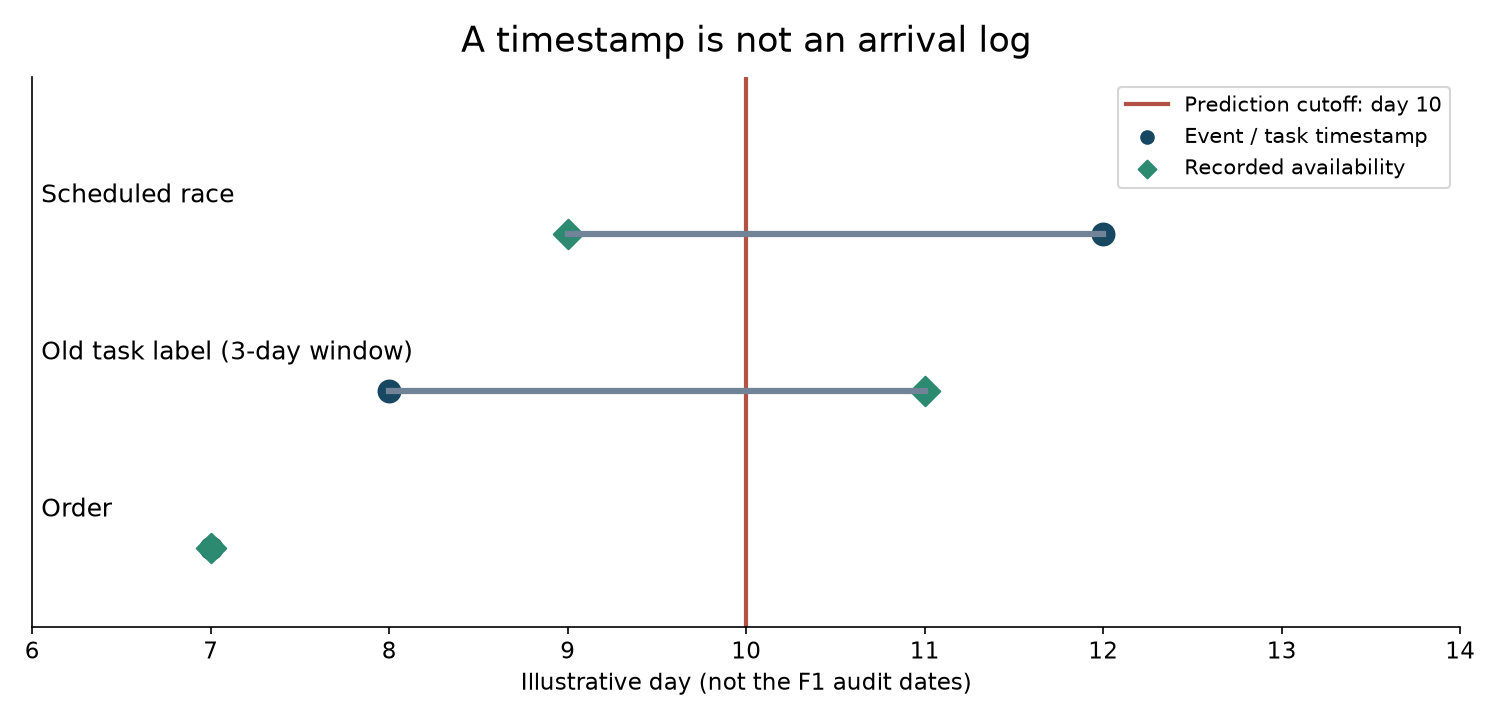

This is the stricter course policy, not the released sampler. Predict whether changing a future amount can change the query output. The constructed query remains in the context; candidate evidence is filtered.

In [18]:
def prediction_with_future(amount):
    event=torch.tensor([2.,5.,12.]);arrival=event.clone();is_label=torch.zeros(3,dtype=torch.bool)
    keep=eligible_rows(event,arrival,10.,is_label,3.)
    values=torch.tensor([2.,6.,amount])
    x=typed_fixture(0);x['number_values'][0,4]=values[keep].mean().double()
    return model(x)[1]['boolean'][0,0].detach()
assert torch.equal(prediction_with_future(30.),prediction_with_future(30000.))
print('CHECK: excluded future evidence cannot alter the prediction')

CHECK: excluded future evidence cannot alter the prediction


## PROVIDED / CHECK · complete real saved-context replay

The next visible auditor authenticates every input, reconstructs all2106labels from raw results, checks702unique driver/cutoff keys per seed and rechecks all2,156,544cell slots. It is fresh analysis of saved data, not fresh native sampling or checkpoint inference.

In [19]:
"""Fresh B10 replay of authenticated L175 saved contexts. No native resampling."""
import hashlib,json
from pathlib import Path
import numpy as np
import ml_dtypes
S=P/'sources/b10';E=P/'evidence/b10'

def audit():
    ledger=json.loads((S/'source-ledger.json').read_text())
    for name,digest in ledger['inherited_contexts'].items():assert hashlib.sha256((P/name).read_bytes()).hexdigest()==digest,name
    meta=json.loads((S/'table_info.json').read_text());cols=json.loads((S/'column_index.json').read_text())
    truth=np.load(P/'evidence/l175/label-oracle.npz');target=cols['did_not_finish of driver-dnf'];rows=[];witnesses=[];reference=None
    for seed in range(3):
      a=np.load(P/f'evidence/l175/audit-3/contexts-{seed}.npz');assert a['node_idxs'].shape==(702,1024)
      summary=dict(seed=seed,queries=702,slots=702*1024,future_cells=0,future_contexts=0,exposed_query_targets=0,unfinished_labels=0,unknown_time_cells=0,visible_labels=0,positives=0)
      keys=[];query_nodes=[]
      for i in range(702):
        q=a['is_targets'][i];assert q.sum()==1;ts=a['timestamps'][i].astype(np.int64);pad=a['is_padding'][i];hidden=a['masks'][i];node=a['node_idxs'][i]
        cutoff=int(ts[q][0]);driver_row=int(a['f2p_nbr_idxs'][i][q][0,0])-meta['drivers:Db']['node_idx_offset'];driver=int(truth['driver_ids'][driver_row]);keys.append((driver,cutoff));query_nodes.append(int(node[q][0]))
        label=int(a['boolean_values'][i][q].view(ml_dtypes.bfloat16).astype(float)[0]>0)
        hits=(truth['driver']==driver)&(truth['time']>cutoff)&(truth['time']<=cutoff+30*86400)
        assert hits.any() and label==int((truth['status'][hits]!=1).any());summary['positives']+=label
        known=ts!=np.iinfo(np.int32).min;future=(ts>cutoff)&~pad&known
        visible=(a['col_name_idxs'][i]==target)&~pad&~hidden
        summary['future_cells']+=int(future.sum());summary['future_contexts']+=int(future.any())
        summary['exposed_query_targets']+=int((q&~hidden&~pad).sum())
        summary['unfinished_labels']+=int((visible&known&(ts+30*86400>cutoff)).sum())
        summary['unknown_time_cells']+=int((~pad&~known).sum());summary['visible_labels']+=int(visible.sum())
        if future.any() and not any(w['seed']==seed for w in witnesses):
          j=int(np.flatnonzero(future)[0]);witnesses.append(dict(seed=seed,driver=driver,cutoff=cutoff,future_time=int(ts[j]),column=next(k for k,v in cols.items() if v==int(a['col_name_idxs'][i,j]))))
      assert len(set(keys))==702 and sorted(query_nodes)==list(range(97606,98308))
      if reference is None:reference=set(keys)
      assert set(keys)==reference;rows.append(summary)
    totals={k:sum(x[k] for x in rows) for k in rows[0] if k!='seed'}
    assert (totals['future_cells'],totals['future_contexts'],totals['unknown_time_cells'])==(385,77,432050)
    assert totals['exposed_query_targets']==totals['unfinished_labels']==0
    result={'status':'COMPLETE_SAVED_CONTEXT_REPLAY','paper_gate':'INCOMPLETE_TEMPORAL_GATE','per_seed':rows,'totals':totals,'witnesses':witnesses,'benchmark_inference':'NOT_RUN','native_resampling':'NOT_RUN','checkpoint_authentication':'NOT_RUN','interpretation':'Event-time rule fails. Scheduled fields might have been available earlier; historical availability is NOT_ESTABLISHED. Unknown timestamp is not proof of future leakage.'}
    (E/'temporal-audit.json').write_text(json.dumps(result,indent=2)+'\n');print(json.dumps(result,indent=2));return result

report=audit()
assert report["totals"]["future_cells"]==385
assert report["paper_gate"]=="INCOMPLETE_TEMPORAL_GATE"

{
  "status": "COMPLETE_SAVED_CONTEXT_REPLAY",
  "paper_gate": "INCOMPLETE_TEMPORAL_GATE",
  "per_seed": [
    {
      "seed": 0,
      "queries": 702,
      "slots": 718848,
      "future_cells": 130,
      "future_contexts": 26,
      "exposed_query_targets": 0,
      "unfinished_labels": 0,
      "unknown_time_cells": 144234,
      "visible_labels": 9986,
      "positives": 495
    },
    {
      "seed": 1,
      "queries": 702,
      "slots": 718848,
      "future_cells": 130,
      "future_contexts": 26,
      "exposed_query_targets": 0,
      "unfinished_labels": 0,
      "unknown_time_cells": 143914,
      "visible_labels": 10001,
      "positives": 495
    },
    {
      "seed": 2,
      "queries": 702,
      "slots": 718848,
      "future_cells": 125,
      "future_contexts": 25,
      "exposed_query_targets": 0,
      "unfinished_labels": 0,
      "unknown_time_cells": 143902,
      "visible_labels": 10001,
      "positives": 495
    }
  ],
  "totals": {
    "queries": 2106,


## Interpret author and live evidence

| Seed | Max output error | Max parameter-gradient error | Permutation error | Hidden-target prediction change |
|---|---:|---:|---:|---:|
| 0 | 3.33e-16 | 2.22e-16 | 4.44e-16 | 0.0 |
| 1 | 4.44e-16 | 9.71e-17 | 6.66e-16 | 0.0 |
| 2 | 3.33e-16 | 2.78e-16 | 6.66e-16 | 0.0 |

All three pass the predeclared **1e-9 absolute tolerance**. Loss and floating-input gradients also pass. The 8,400 pair checks include padding; three wrong learner functions are rejected. These are numerical verification errors, not benchmark metric improvements.

The table above is author-reference evidence. The CHECK outputs above it are from your current kernel. Both are finite-fixture mechanism evidence. In the real saved contexts,385future-dated cells occur in77contexts while query targets remain hidden. Race schedules might have been known earlier, but no arrival logs prove that.432,050untimed cells also lack an availability proof.

No target gradients does not mean no contextual labels. An unseen task is not necessarily an unseen database. Changing schema names changes inputs and is not a row-permutation test.

## EXIT · written defense

Submit your three functions, CHECK outputs and150words tracing T0.y through context selection, typed masking and the four attention operations. Explain why changing hidden truth affects loss but not predictions; why scheduled future fields need a declared policy; and why82.0%AUROC remains a paper claim. Learner status **PENDING_WRITTEN_DEFENSE**. Repeat the mask trace after1/7/30days. Ask the teaching agent about unclear steps.

B11 compares RelGNN/RelGT under matched relational evidence. Identify which units are rows and which are cells before comparing architectures.

## NEXT STEP · named paper target and full source

RT-v1 Table1, rel-f1/driver-dnf, reported82.0%AUROC. Original12×256model,1024cells,BFS256, full702queries, seed0 plus robustness1/2; original data and weight revisions pinned in the packet. No inference or fresh training has run. Checkpoint bytes remain unauthenticated. The GPU path after the gate remains unvalidated. Full pretraining and whole-paper reproduction are NOT_RUN.

Repository command: `.venv/bin/python labs/_budget_b10.py .venv/bin/python labs/_reproduce_b10.py`. Explicit `--run` recomputes the gate and refuses. The3600second aggregate local budget includes preparation/retries/checks; USD0paid. Live Colab and deployment are not verified. Do not replace RT-v1 with the current RT-J quickstart.

In [20]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    # Recheck actual packaged data; no editable PASS flag can bypass this gate.
    current=audit()
    if current['paper_gate']!='PASS':
        raise RuntimeError('BLOCKED_TEMPORAL_AUDIT: checkpoint inference NOT_RUN')
    raise RuntimeError('Use the isolated original-runtime operator with authenticated weights')
print('Paper lane: INCOMPLETE_TEMPORAL_GATE; inference NOT_RUN')

Paper lane: INCOMPLETE_TEMPORAL_GATE; inference NOT_RUN


## Source appendix · original model and trainer

Unmodified pinned source is readable below; it is not executed again by these appendix cells. Preserve source/release attribution. The backend adapter above is the only source-parity execution substitution. Original model and trainer are separate from the reduced teaching fixture.

### upstream/rt/model.py

```python
import json
import os
from functools import partial
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from einops import rearrange
from einops._torch_specific import allow_ops_in_compiled_graph
from ml_dtypes import bfloat16
from torch import nn
from torch.nn.attention import SDPBackend, sdpa_kernel
from torch.nn.attention.flex_attention import create_block_mask, flex_attention

allow_ops_in_compiled_graph()
flex_attention = torch.compile(flex_attention)


class MaskedAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads

        self.wq = nn.Linear(d_model, d_model, bias=False)
        self.wk = nn.Linear(d_model, d_model, bias=False)
        self.wv = nn.Linear(d_model, d_model, bias=False)
        self.wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, block_mask):
        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        q = rearrange(q, "b s (h d) -> b h s d", h=self.num_heads)
        k = rearrange(k, "b s (h d) -> b h s d", h=self.num_heads)
        v = rearrange(v, "b s (h d) -> b h s d", h=self.num_heads)

        if block_mask is None:
            with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
                x = F.scaled_dot_product_attention(q, k, v)
        else:
            x = flex_attention(q, k, v, block_mask=block_mask)

        x = rearrange(x, "b h s d -> b s (h d)")
        x = self.wo(x)
        return x


class FFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.w1 = nn.Linear(d_model, d_ff, bias=False)
        self.w2 = nn.Linear(d_ff, d_model, bias=False)
        self.w3 = nn.Linear(d_model, d_ff, bias=False)

    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))


class RelationalBlock(nn.Module):
    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
    ):
        super().__init__()

        self.norms = nn.ModuleDict(
            {l: nn.RMSNorm(d_model) for l in ["feat", "nbr", "col", "full", "ffn"]}
        )
        self.attns = nn.ModuleDict(
            {
                l: MaskedAttention(d_model, num_heads)
                for l in ["feat", "nbr", "col", "full"]
            }
        )
        self.ffn = FFN(d_model, d_ff)

    def forward(self, x, block_masks):
        for l in ["col", "feat", "nbr", "full"]:
            x = x + self.attns[l](self.norms[l](x), block_mask=block_masks[l])
        x = x + self.ffn(self.norms["ffn"](x))
        return x


def _make_block_mask(mask, batch_size, seq_len, device):
    def _mod(b, h, q_idx, kv_idx):
        return mask[b, q_idx, kv_idx]

    return create_block_mask(
        mask_mod=_mod,
        B=batch_size,
        H=None,
        Q_LEN=seq_len,
        KV_LEN=seq_len,
        device=device,
        _compile=True,
    )


class RelationalTransformer(nn.Module):
    def __init__(
        self,
        num_blocks,
        d_model,
        d_text,
        num_heads,
        d_ff,
    ):
        super().__init__()

        self.enc_dict = nn.ModuleDict(
            {
                "number": nn.Linear(1, d_model, bias=True),
                "text": nn.Linear(d_text, d_model, bias=True),
                "datetime": nn.Linear(1, d_model, bias=True),
                "col_name": nn.Linear(d_text, d_model, bias=True),
                "boolean": nn.Linear(1, d_model, bias=True),
            }
        )
        self.dec_dict = nn.ModuleDict(
            {
                "number": nn.Linear(d_model, 1, bias=True),
                "text": nn.Linear(d_model, d_text, bias=True),
                "datetime": nn.Linear(d_model, 1, bias=True),
                "boolean": nn.Linear(d_model, 1, bias=True),
            }
        )
        self.norm_dict = nn.ModuleDict(
            {
                "number": nn.RMSNorm(d_model),
                "text": nn.RMSNorm(d_model),
                "datetime": nn.RMSNorm(d_model),
                "col_name": nn.RMSNorm(d_model),
                "boolean": nn.RMSNorm(d_model),
            }
        )
        self.mask_embs = nn.ParameterDict(
            {
                t: nn.Parameter(torch.randn(d_model))
                for t in ["number", "text", "datetime", "boolean"]
            }
        )
        self.blocks = nn.ModuleList(
            [RelationalBlock(d_model, num_heads, d_ff) for i in range(num_blocks)]
        )
        self.norm_out = nn.RMSNorm(d_model)
        self.d_model = d_model

    def forward(self, batch):
        node_idxs = batch["node_idxs"]
        f2p_nbr_idxs = batch["f2p_nbr_idxs"]
        col_name_idxs = batch["col_name_idxs"]
        table_name_idxs = batch["table_name_idxs"]
        is_padding = batch["is_padding"]
        batch_size, seq_len = node_idxs.shape

        batch_size, seq_len = node_idxs.shape
        device = node_idxs.device

        # Padding mask for attention pairs (allow only non-pad -> non-pad)
        pad = (~is_padding[:, :, None]) & (~is_padding[:, None, :])  # (B, S, S)

        # cells in the same node
        same_node = node_idxs[:, :, None] == node_idxs[:, None, :]  # (B, S, S)

        # kv index is among q's foreign -> primary neighbors
        kv_in_f2p = (node_idxs[:, None, :, None] == f2p_nbr_idxs[:, :, None, :]).any(
            -1
        )  # (B, S, S)

        # q index is among kv's primary -> foreign neighbors (reverse relation)
        q_in_f2p = (node_idxs[:, :, None, None] == f2p_nbr_idxs[:, None, :, :]).any(
            -1
        )  # (B, S, S)

        # Same column AND same table
        same_col_table = (col_name_idxs[:, :, None] == col_name_idxs[:, None, :]) & (
            table_name_idxs[:, :, None] == table_name_idxs[:, None, :]
        )  # (B, S, S)

        # Final boolean masks (apply padding once here)
        attn_masks = {
            "feat": (same_node | kv_in_f2p) & pad,
            "nbr": q_in_f2p & pad,
            "col": same_col_table & pad,
            "full": pad,
        }

        # Make them contiguous for better kernel performance
        for l in attn_masks:
            attn_masks[l] = attn_masks[l].contiguous()

        # Convert to block masks
        make_block_mask = partial(
            _make_block_mask,
            batch_size=batch_size,
            seq_len=seq_len,
            device=device,
        )
        block_masks = {
            l: make_block_mask(attn_mask) for l, attn_mask in attn_masks.items()
        }

        x = 0
        x = x + (
            self.norm_dict["col_name"](
                self.enc_dict["col_name"](batch["col_name_values"])
            )
            * (~is_padding)[..., None]
        )

        for i, t in enumerate(["number", "text", "datetime", "boolean"]):
            x = x + (
                self.norm_dict[t](self.enc_dict[t](batch[t + "_values"]))
                * ((batch["sem_types"] == i) & ~batch["masks"] & ~is_padding)[..., None]
            )
            x = x + (
                self.mask_embs[t]
                * ((batch["sem_types"] == i) & batch["masks"] & ~is_padding)[..., None]
            )

        for i, block in enumerate(self.blocks):
            x = block(x, block_masks)

        x = self.norm_out(x)

        loss_out = x.new_zeros(())
        yhat_out = {"number": None, "text": None, "datetime": None, "boolean": None}

        B, S, _ = x.shape
        sem_types = batch["sem_types"]  # (B,S) ints 0..3
        masks = batch["masks"].bool()  # (B,S) where to train

        for i, t in enumerate(["number", "text", "datetime", "boolean"]):
            yhat = self.dec_dict[t](x)  # (B,S, D_t)
            y = batch[f"{t}_values"]  # (B,S, D_y)
            sem_type_mask = (sem_types == i) & masks  # (B,S) mask for this type

            if not sem_type_mask.any():
                if t in yhat_out:
                    # still touch the param to avoid unused param error
                    loss_out = loss_out + (yhat.sum() * 0.0)
                    yhat_out[t] = yhat
                continue

            if t in ("number", "datetime"):
                loss_t = F.huber_loss(yhat, y, reduction="none").mean(-1)
            elif t == "boolean":
                loss_t = F.binary_cross_entropy_with_logits(
                    yhat, (y > 0).float(), reduction="none"
                ).mean(-1)
            elif t == "text":
                raise ValueError("masking text not supported")

            # masked sum for this type
            loss_out = loss_out + (loss_t * sem_type_mask).sum()

            if t in yhat_out:
                yhat_out[t] = yhat

        loss_out = loss_out / masks.sum()

        return loss_out, yhat_out

```

### upstream/rt/main.py

```python
import os
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.distributed as dist
import wandb
from sklearn.metrics import r2_score, roc_auc_score
from torch import optim
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.nn.utils import clip_grads_with_norm_, get_total_norm
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from rt.data import RelationalDataset
from rt.model import RelationalTransformer


def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False


def all_gather_nd(tensor: torch.Tensor) -> list[torch.Tensor]:
    """
    Gathers tensor arrays of different lengths in a list.
    The length dimension is 0. This supports any number of extra dimensions in the tensors.
    All the other dimensions should be equal between the tensors.
    Adapted from: https://stackoverflow.com/a/71433508

    Args:
        tensor (Tensor): Tensor to be broadcast from current process.

    Returns:
        list[Tensor]: List of tensors gathered from all processes.
    """
    world_size = dist.get_world_size()
    local_size = torch.tensor(tensor.size(), device=tensor.device)
    all_sizes = [torch.zeros_like(local_size) for _ in range(world_size)]
    dist.all_gather(all_sizes, local_size)

    max_length = max(size[0] for size in all_sizes)

    length_diff = max_length.item() - local_size[0].item()
    if length_diff:
        pad_size = (length_diff, *tensor.size()[1:])
        padding = torch.zeros(pad_size, device=tensor.device, dtype=tensor.dtype)
        tensor = torch.cat((tensor, padding))

    all_tensors_padded = [torch.zeros_like(tensor) for _ in range(world_size)]
    dist.all_gather(all_tensors_padded, tensor)
    all_tensors = []
    for tensor_, size in zip(all_tensors_padded, all_sizes):
        all_tensors.append(tensor_[: size[0]])
    return all_tensors


def main(
    # misc
    project,
    eval_splits,
    eval_freq,
    eval_pow2,
    max_eval_steps,
    load_ckpt_path,
    save_ckpt_dir,
    compile_,
    seed,
    # data
    train_tasks,
    eval_tasks,
    batch_size,
    num_workers,
    max_bfs_width,
    # optimization
    lr,
    wd,
    lr_schedule,
    max_grad_norm,
    max_steps,
    # model
    embedding_model,
    d_text,
    seq_len,
    num_blocks,
    d_model,
    num_heads,
    d_ff,
):
    seed_everything(seed)

    ddp = "LOCAL_RANK" in os.environ
    device = "cuda"
    if ddp:
        os.environ["OMP_NUM_THREADS"] = f"{num_workers}"
        torch.cuda.set_device(int(os.environ["LOCAL_RANK"]))
        dist.init_process_group("nccl")
    if ddp:
        rank = dist.get_rank()
        world_size = dist.get_world_size()
    else:
        rank = 0
        world_size = 1

    if rank == 0:
        run = wandb.init(project=project, config=locals())
        print(run.name)

    torch.multiprocessing.set_sharing_strategy("file_system")
    torch._dynamo.config.cache_size_limit = 16
    torch._dynamo.config.compiled_autograd = compile_ if ddp else False
    torch._dynamo.config.optimize_ddp = True
    torch.set_num_threads(1)

    dataset = RelationalDataset(
        tasks=[
            (db_name, table_name, target_column, "train", columns_to_drop)
            for db_name, table_name, target_column, columns_to_drop in train_tasks
        ],
        batch_size=batch_size,
        seq_len=seq_len,
        rank=rank,
        world_size=world_size,
        max_bfs_width=max_bfs_width,
        embedding_model=embedding_model,
        d_text=d_text,
        seed=seed,
    )
    loader = DataLoader(
        dataset,
        batch_size=None,
        num_workers=num_workers,
        persistent_workers=False,
        pin_memory=True,
        in_order=True,
    )

    eval_loaders = {}
    for db_name, table_name, target_column, columns_to_drop in eval_tasks:
        for split in eval_splits:
            eval_dataset = RelationalDataset(
                tasks=[(db_name, table_name, target_column, split, columns_to_drop)],
                batch_size=batch_size,
                seq_len=seq_len,
                rank=rank,
                world_size=world_size,
                max_bfs_width=max_bfs_width,
                embedding_model=embedding_model,
                d_text=d_text,
                seed=0,
            )
            eval_dataset.sampler.shuffle_py(0)
            eval_loaders[(db_name, table_name, split)] = DataLoader(
                eval_dataset,
                batch_size=None,
                num_workers=num_workers,
                persistent_workers=True,
                pin_memory=True,
                in_order=True,
            )

    net = RelationalTransformer(
        num_blocks=num_blocks,
        d_model=d_model,
        d_text=d_text,
        num_heads=num_heads,
        d_ff=d_ff,
    )
    if load_ckpt_path is not None:
        load_ckpt_path = Path(load_ckpt_path).expanduser()
        state_dict = torch.load(load_ckpt_path, map_location="cpu")
        net.load_state_dict(state_dict)

    if rank == 0:
        param_count = sum(p.numel() for p in net.parameters())
        print(f"{param_count=:_}")

    net = net.to(device)
    net = net.to(torch.bfloat16)
    opt = optim.AdamW(
        net.parameters(),
        lr=lr,
        weight_decay=wd,
        betas=(0.9, 0.999),
        eps=1e-8,
        fused=True,
    )

    if lr_schedule:
        lrs = optim.lr_scheduler.OneCycleLR(
            opt,
            max_lr=lr,
            total_steps=max_steps,
            pct_start=0.2,
            anneal_strategy="linear",
        )

    if ddp:
        net = DDP(net)

    net = torch.compile(net, dynamic=False, disable=not compile_)

    steps = 0
    if rank == 0:
        wandb.log({"epochs": 0}, step=steps)

    eval_loader_iters = {}
    for k, eval_loader in eval_loaders.items():
        eval_loader_iters[k] = iter(eval_loader)

    def evaluate(net):
        metrics = {"val": {}, "test": {}}
        net.eval()
        with torch.inference_mode():
            for (
                db_name,
                table_name,
                split,
            ), eval_loader_iter in eval_loader_iters.items():
                if table_name in [
                    "item-sales",
                    "user-ltv",
                    "item-ltv",
                    "post-votes",
                    "site-success",
                    "study-adverse",
                    "user-attendance",
                    "driver-position",
                    "ad-ctr",
                ]:
                    task_type = "reg"
                else:
                    task_type = "clf"

                preds = []
                labels = []
                losses = []
                eval_load_times = []
                eval_loader = eval_loaders[(db_name, table_name, split)]
                pbar = tqdm(
                    total=(
                        min(max_eval_steps, len(eval_loader))
                        if max_eval_steps > -1
                        else len(eval_loader)
                    ),
                    desc=f"{db_name}/{table_name}/{split}",
                    disable=rank != 0,
                )

                batch_idx = 0
                while True:
                    tic = time.time()
                    try:
                        batch = next(eval_loader_iter)
                        batch_idx += 1
                    except StopIteration:
                        break
                    toc = time.time()
                    pbar.update(1)

                    eval_load_time = toc - tic
                    if rank == 0:
                        eval_load_times.append(eval_load_time)

                    true_batch_size = batch.pop("true_batch_size")
                    for k in batch:
                        batch[k] = batch[k].to(device, non_blocking=True)

                    batch["masks"][true_batch_size:, :] = False
                    batch["is_targets"][true_batch_size:, :] = False
                    batch["is_padding"][true_batch_size:, :] = True

                    loss, yhat_dict = net(batch)

                    if task_type == "clf":
                        yhat = yhat_dict["boolean"][batch["is_targets"]]
                        y = batch["boolean_values"][batch["is_targets"]].flatten()
                    elif task_type == "reg":
                        yhat = yhat_dict["number"][batch["is_targets"]]
                        y = batch["number_values"][batch["is_targets"]].flatten()

                    assert yhat.size(0) == true_batch_size
                    assert y.size(0) == true_batch_size

                    pred = yhat.flatten()

                    losses.append(loss.item())
                    preds.append(pred)
                    labels.append(y)

                    if max_eval_steps > -1 and batch_idx >= max_eval_steps:
                        break

                eval_loader_iters[(db_name, table_name, split)] = iter(eval_loader)

                pbar.close()
                preds = torch.cat(preds, dim=0)
                labels = torch.cat(labels, dim=0)

                if ddp:
                    # ensure the predictions and labels are gathered jointly
                    preds = all_gather_nd(preds)
                    labels = all_gather_nd(labels)
                else:
                    preds = [preds]
                    labels = [labels]

                if rank == 0:
                    loss = sum(losses) / len(losses)
                    k = f"loss/{db_name}/{table_name}/{split}"
                    avg_eval_load_time = sum(eval_load_times) / len(eval_load_times)
                    wandb.log(
                        {
                            k: loss,
                            f"avg_eval_load_time/{db_name}/{table_name}": avg_eval_load_time,
                        },
                        step=steps,
                    )

                    preds = torch.cat(preds, dim=0).float().cpu().numpy()
                    labels = torch.cat(labels, dim=0).float().cpu().numpy()

                    if task_type == "reg":
                        metric_name = "r2"
                        metric = r2_score(labels, preds)
                    elif task_type == "clf":
                        metric_name = "auc"
                        labels = [int(x > 0) for x in labels]
                        metric = roc_auc_score(labels, preds)

                    k = f"{metric_name}/{db_name}/{table_name}/{split}"
                    wandb.log({k: metric}, step=steps)
                    print(f"\nstep={steps}, \t{k}: {metric}")
                    metrics[split][(db_name, table_name)] = metric

        return metrics

    def checkpoint(best=False, db_name="", table_name=""):
        if rank != 0:
            return
        save_ckpt_dir_ = Path(save_ckpt_dir).expanduser()
        save_ckpt_dir_.mkdir(parents=True, exist_ok=True)
        if best:
            save_ckpt_path = f"{save_ckpt_dir_}/{db_name}_{table_name}_best.pt"
        else:
            save_ckpt_path = f"{save_ckpt_dir_}/{steps=}.pt"

        state_dict = net.module.state_dict() if ddp else net.state_dict()
        torch.save(state_dict, save_ckpt_path)
        print(f"saved checkpoint to {save_ckpt_path}")

    pbar = tqdm(
        total=max_steps,
        desc="steps",
        disable=rank != 0,
    )

    best_val_metrics = dict()
    best_test_metrics = dict()

    while steps < max_steps:
        loader.dataset.sampler.shuffle_py(int(steps / len(loader)))
        loader_iter = iter(loader)
        while steps < max_steps:
            if (eval_freq is not None and steps % eval_freq == 0) or (
                eval_pow2 and steps & (steps - 1) == 0
            ):
                metrics = evaluate(net)
                if save_ckpt_dir is not None:
                    # RT_SAVE_ALL_STEPS=1 -> snapshot every eval step (steps=N.pt) so a caller can
                    # post-hoc select by a metric other than the val-R2/AUC used here (e.g. val-NMAE
                    # for regression). Off by default (preserves original behaviour).
                    if os.environ.get("RT_SAVE_ALL_STEPS") == "1":
                        checkpoint()
                    for (db_name, table_name), metric in metrics["val"].items():
                        # Eval metric is always higher is better (auc, r2)
                        best_metric = best_val_metrics.get(
                            (db_name, table_name), -float("inf")
                        )
                        if metric > best_metric:
                            best_val_metrics[(db_name, table_name)] = metric
                            best_test_metrics[(db_name, table_name)] = metrics["test"][(db_name, table_name)]
                            checkpoint(
                                best=True,
                                db_name=db_name,
                                table_name=table_name
                            )
                        else:
                            checkpoint()

            net.train()

            tic = time.time()
            try:
                batch = next(loader_iter)
            except StopIteration:
                break
            batch.pop("true_batch_size")
            for k in batch:
                batch[k] = batch[k].to(device, non_blocking=True)
            toc = time.time()
            load_time = toc - tic
            if rank == 0:
                wandb.log({"load_time": load_time}, step=steps)

            loss, _yhat_dict = net(batch)
            opt.zero_grad(set_to_none=True)
            loss.backward()

            grad_norm = get_total_norm(
                [p.grad for p in net.parameters() if p.grad is not None]
            )
            clip_grads_with_norm_(
                net.parameters(), max_norm=max_grad_norm, total_norm=grad_norm
            )

            opt.step()
            if lr_schedule:
                lrs.step()

            steps += 1

            if ddp:
                dist.all_reduce(loss, op=dist.ReduceOp.AVG)
            if rank == 0:
                wandb.log(
                    {
                        "loss": loss,
                        "lr": opt.param_groups[0]["lr"],
                        "epochs": steps / len(loader),
                        "grad_norm": grad_norm,
                    },
                    step=steps,
                )

            pbar.update(1)

    # Print best test metrics
    if rank == 0:
        print("\n" + "="*80)
        print("Best test metrics:")
        print("="*80)
        for (db_name, table_name), metric in best_test_metrics.items():
            print(f"{db_name}/{table_name}/test: {metric:.4f}")
        print("="*80 + "\n")

    if ddp:
        dist.destroy_process_group()


if __name__ == "__main__":
    import strictfire

    strictfire.StrictFire(main)

```

### upstream/rt/data.py

```python
import maturin_import_hook
from maturin_import_hook.settings import MaturinSettings

maturin_import_hook.install(settings=MaturinSettings(release=True, uv=True))

import json
import os
from functools import cache

import ml_dtypes
import numpy as np
import torch
from rustler import Sampler
from torch.utils.data import Dataset


@cache
def _load_column_index(db_name: str) -> dict:
    """
    Load the column index mapping for a dataset (cached).
    """
    home = os.environ.get("HOME", ".")
    column_index_path = os.path.join(
        home, "scratch", "pre", db_name, "column_index.json"
    )

    with open(column_index_path) as f:
        return json.load(f)


def get_column_index(column_name: str, table_name: str, db_name: str) -> int:
    """
    Get the index of a column in the text embeddings for a given dataset.
    """
    column_index = _load_column_index(db_name)
    target = f"{column_name} of {table_name}"

    if target not in column_index:
        raise ValueError(
            f'Column "{target}" not found in column_index.json for dataset {db_name}.'
        )

    return column_index[target]


class RelationalDataset(Dataset):
    def __init__(
        self,
        tasks,
        batch_size,
        seq_len,
        rank,
        world_size,
        max_bfs_width,
        embedding_model,
        d_text,
        seed,
    ):
        dataset_tuples = []
        target_column_indices = []
        drop_column_indices = []

        for db_name, table_name, target_column, split, columns_to_drop in tasks:
            if split == "train":
                split = "Train"
            elif split == "val":
                split = "Val"
            elif split == "test":
                split = "Test"

            table_info_path = (
                f"{os.environ['HOME']}/scratch/pre/{db_name}/table_info.json"
            )
            with open(table_info_path) as f:
                table_info = json.load(f)

            table_info_key = (
                f"{table_name}:Db"
                if f"{table_name}:Db" in table_info
                else f"{table_name}:{split}"
            )
            info = table_info[table_info_key]
            node_idx_offset = info["node_idx_offset"]
            num_nodes = info["num_nodes"]

            target_idx = get_column_index(target_column, table_name, db_name)
            target_column_indices.append(target_idx)

            drop_indices = [
                get_column_index(col, table_name, db_name) for col in columns_to_drop
            ]
            drop_column_indices.append(drop_indices)

            dataset_tuples.append((db_name, node_idx_offset, num_nodes))

        self.sampler = Sampler(
            dataset_tuples=dataset_tuples,
            batch_size=batch_size,
            seq_len=seq_len,
            rank=rank,
            world_size=world_size,
            max_bfs_width=max_bfs_width,
            embedding_model=embedding_model,
            d_text=d_text,
            seed=seed,
            target_columns=target_column_indices,
            columns_to_drop=drop_column_indices,
        )

        self.seq_len = seq_len
        self.d_text = d_text

    def __len__(self):
        return self.sampler.len_py()

    def __getitem__(self, batch_idx):
        tup = self.sampler.batch_py(batch_idx)
        out = dict(tup)
        for k, v in out.items():
            if k in [
                "number_values",
                "datetime_values",
                "text_values",
                "col_name_values",
                "boolean_values",
            ]:
                out[k] = torch.from_numpy(v.view(np.float16)).view(torch.bfloat16)
            elif k == "true_batch_size":
                pass
            else:
                out[k] = torch.from_numpy(v)

        out["node_idxs"] = out["node_idxs"].view(-1, self.seq_len)
        out["sem_types"] = out["sem_types"].view(-1, self.seq_len)
        out["masks"] = out["masks"].view(-1, self.seq_len)
        out["is_targets"] = out["is_targets"].view(-1, self.seq_len)
        out["is_task_nodes"] = out["is_task_nodes"].view(-1, self.seq_len)
        out["is_padding"] = out["is_padding"].view(-1, self.seq_len)
        out["timestamps"] = out["timestamps"].view(-1, self.seq_len)
        out["table_name_idxs"] = out["table_name_idxs"].view(-1, self.seq_len)
        out["col_name_idxs"] = out["col_name_idxs"].view(-1, self.seq_len)
        out["class_value_idxs"] = out["class_value_idxs"].view(-1, self.seq_len)

        out["f2p_nbr_idxs"] = out["f2p_nbr_idxs"].view(-1, self.seq_len, 5)
        out["number_values"] = out["number_values"].view(-1, self.seq_len, 1)
        out["datetime_values"] = out["datetime_values"].view(-1, self.seq_len, 1)
        out["boolean_values"] = (
            out["boolean_values"].view(-1, self.seq_len, 1).bfloat16()
        )
        out["text_values"] = out["text_values"].view(-1, self.seq_len, self.d_text)
        out["col_name_values"] = out["col_name_values"].view(
            -1, self.seq_len, self.d_text
        )

        return out

```

### example_pretrain.py

```python
from rt.main import main
from rt.tasks import all_tasks, forecast_tasks

if __name__ == "__main__":
    main(
        # misc
        project="rt",
        eval_splits=["val", "test"],
        eval_freq=1_000,
        eval_pow2=True,
        max_eval_steps=40,
        load_ckpt_path=None,
        save_ckpt_dir="ckpts/leave_rel-amazon",
        compile_=True,
        seed=0,
        # data
        train_tasks=[t for t in all_tasks if t[0] != "rel-amazon"],
        eval_tasks=[t for t in forecast_tasks if t[0] == "rel-amazon"],
        batch_size=32,
        num_workers=8,
        max_bfs_width=256,
        # optimization
        lr=1e-3,
        wd=0.1,
        lr_schedule=True,
        max_grad_norm=1.0,
        max_steps=50_001,
        # model
        embedding_model="all-MiniLM-L12-v2",
        d_text=384,
        seq_len=1024,
        num_blocks=12,
        d_model=256,
        num_heads=8,
        d_ff=1024,
    )

```

### example_finetune.py

```python
from rt.main import main
from rt.tasks import all_tasks, forecast_tasks

if __name__ == "__main__":
    main(
        # misc
        project="rt",
        eval_splits=["val", "test"],
        eval_freq=1_000,
        eval_pow2=False,
        max_eval_steps=40,
        load_ckpt_path="ckpts/rel-amazon_user-churn/rel-amazon_user-churn_best.pt",
        # load_ckpt_path="~/scratch/rt_ckpts/pretrain_rel-amazon_user-churn.pt",
        save_ckpt_dir=None,
        compile_=True,
        seed=0,
        # data
        train_tasks=[("rel-amazon", "user-churn", "churn", [])],
        eval_tasks=[("rel-amazon", "user-churn", "churn", [])],
        batch_size=32,
        num_workers=8,
        max_bfs_width=256,
        # optimization
        lr=1e-4,
        wd=0.0,
        lr_schedule=False,
        max_grad_norm=1.0,
        max_steps=2**15 + 1,
        # model
        embedding_model="all-MiniLM-L12-v2",
        d_text=384,
        seq_len=1024,
        num_blocks=12,
        d_model=256,
        num_heads=8,
        d_ff=1024,
    )

```

### Selected native inference operator (post-gate path unvalidated)

```python
"""Selected three-run RT-v1 inference operator. Refuses a failed context audit.

Requires the pinned rt-v1 source, its native sampler, original preprocessed F1
under ~/scratch/pre/rel-f1, and the pretrained checkpoint file. No training or selection.
"""
import argparse,hashlib,json,sys,time
from pathlib import Path
import numpy as np

def run(source,checkpoints,audit_dir,out):
    audit=json.loads((Path(audit_dir)/'context-audit.json').read_text())
    if audit['inference_gate']!='PASS' or any(audit['summary'][k]['cells'] for k in ['unmasked_query_targets','unavailable_labels','future_cells']):
        raise RuntimeError('BLOCKED_TEMPORAL_AUDIT: do not score an invalid clean evaluation')
    out=Path(out)
    if out.exists():raise FileExistsError('Immutable output: choose a new run directory')
    out.mkdir(parents=True);sys.path.insert(0,str(source))
    import torch
    from rt.data import RelationalDataset
    from rt.model import RelationalTransformer
    from sklearn.metrics import roc_auc_score
    torch.set_num_threads(1)
    files={'pretrain':'pretrain_rel-f1_driver-dnf.pt'}
    driver_ids=np.load(Path(__file__).resolve().parent/'evidence/l175/label-oracle.npz')['driver_ids']
    rows=[];meta=json.loads((Path.home()/'scratch/pre/rel-f1/table_info.json').read_text());driver_offset=meta['drivers:Db']['node_idx_offset']
    for arm,filename in files.items():
        ckpt=Path(checkpoints)/filename
        net=RelationalTransformer(12,256,384,8,1024)
        net.load_state_dict(torch.load(ckpt,map_location='cpu',weights_only=True),strict=True)
        net=net.to('cuda',dtype=torch.bfloat16).eval().requires_grad_(False)
        initial={k:hashlib.sha256(v.detach().cpu().view(torch.uint8).numpy().tobytes()).hexdigest() for k,v in net.state_dict().items()}
        for seed in [0,1,2]:
            start=time.monotonic();ds=RelationalDataset([('rel-f1','driver-dnf','did_not_finish','test',[])],8,1024,0,1,256,'all-MiniLM-L12-v2',384,seed);ds.sampler.shuffle_py(0)
            keys=[];labels=[];logits=[];nodes=[]
            with torch.inference_mode():
                for i in range(len(ds)):
                    batch=ds[i];n=int(batch.pop('true_batch_size'))
                    batch['masks'][n:]=False;batch['is_targets'][n:]=False;batch['is_padding'][n:]=True
                    target=batch['is_targets'];node=batch['node_idxs'][target];cutoff=batch['timestamps'][target]
                    fk=batch['f2p_nbr_idxs'][target][:,0]-driver_offset
                    keys.extend(zip(driver_ids[np.asarray(fk.tolist(),dtype=int)].tolist(),cutoff.tolist()));nodes.extend(node.tolist())
                    labels.extend((batch['boolean_values'][target].flatten()>0).int().tolist())
                    batch={k:v.to('cuda') for k,v in batch.items()};_,pred=net(batch)
                    logits.extend(pred['boolean'][batch['is_targets']].float().flatten().cpu().tolist())
            assert len(set(keys))==len(keys)==702
            assert sorted(nodes)==list(range(97606,98308))
            final={k:hashlib.sha256(v.detach().cpu().view(torch.uint8).numpy().tobytes()).hexdigest() for k,v in net.state_dict().items()};assert initial==final
            np.savez_compressed(out/f'{arm}-{seed}.npz',keys=np.array(keys),labels=labels,logits=logits,nodes=nodes)
            row=dict(arm=arm,seed=seed,n=702,auc=float(roc_auc_score(labels,logits)),seconds=time.monotonic()-start,checkpoint_sha256=hashlib.sha256(ckpt.read_bytes()).hexdigest());rows.append(row)
            (out/'report.json').write_text(json.dumps(rows,indent=2)+'\n')
    return rows
if __name__=='__main__':
    p=argparse.ArgumentParser();p.add_argument('--source',type=Path,required=True);p.add_argument('--checkpoints',type=Path,required=True);p.add_argument('--audit-dir',type=Path,required=True);p.add_argument('--out',type=Path,required=True);a=p.parse_args();print(run(a.source,a.checkpoints,a.audit_dir,a.out))

```